In [1]:
import numpy as np
import matplotlib.pyplot as plt

from squlearn import Executor
from squlearn.encoding_circuit import ChebyshevTower, LayeredEncodingCircuit
from squlearn.kernel.matrix import ProjectedQuantumKernel, KernelOptimizer
from squlearn.kernel.loss.ODE_loss import ODELoss
from squlearn.kernel.ml import QKODE
from squlearn.optimizers import LBFGSB, Adam
import sympy as sp


In [2]:
# enc_circ_L = LayeredEncodingCircuit(num_qubits=4, num_features=1)
# enc_circ_L.Rx("x")
# enc_circ = enc_circ_L

enc_circ = ChebyshevTower(num_qubits=4, num_features=1, num_chebyshev=4, num_layers=1)
pqk = ProjectedQuantumKernel(executor=Executor(), encoding_circuit=enc_circ)


x, f, dfdx, dfdxdx = sp.symbols("x f dfdx dfdxdx")
eq = sp.sin(x) + dfdx + x
initial_values = [1]
lamb, k = 20, 0.1
eq = dfdx - (-lamb * sp.exp(-lamb * x * k) * sp.sin(lamb * x) - lamb * k * f)

# x, f, dfdx, dfdxdx = sp.symbols("x f dfdx dfdxdx")
# eq =  dfdx - sp.exp(-f*1)
# initial_values = [np.log(0.001)]


loss_ODE_squ = ODELoss(
    eq,
    symbols_involved_in_ODE=[x, f, dfdx],
    initial_values=initial_values,
    boundary_handling="pinned",
    eta=0.005
)



In [3]:
x_space = np.linspace(0, 0.9, 100).reshape(-1, 1)
labels = np.zeros((len(x_space), 1))
parameter_values = np.random.rand(len(x_space)+1)

kernel_optimizer = KernelOptimizer(
    pqk,
    loss_ODE_squ,
    optimizer=LBFGSB(),  #Adam({"num_iter":2000, "lr": 0.05, "tol": 1e-10}),
    initial_parameters = parameter_values
)


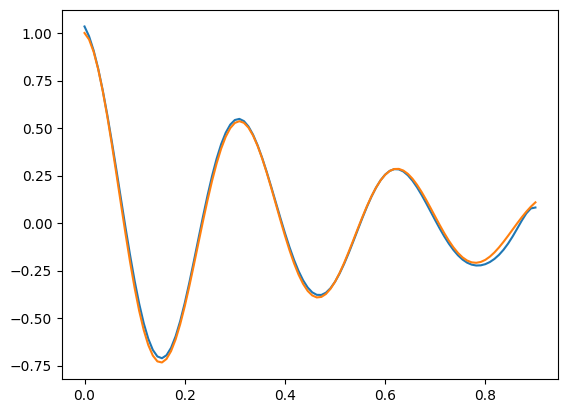

In [4]:
model = QKODE(quantum_kernel=kernel_optimizer)
model.fit(x_space, labels)
plt.plot(x_space, model.predict(x_space))
plt.plot(x_space, np.exp(-20 * x_space * 0.1) * np.cos(20 * x_space))